In [1]:
#| hide

%load_ext autoreload
%autoreload 2

# Single Agent Experiment Results: In-depth SQL

> Here, we see in-depth experiment results for single agents!

- skip_showdoc: true
- skip_exec: true

In [ ]:
#| default_exp visualize_extra

In [16]:
#| hide

import json
from claimdb.configuration import *
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from claimdb.visualize import models, info_dict
from dataclasses import dataclass
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt
from plottable import Table, ColumnDefinition
import random
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix
)

In [17]:
def is_log_openai(log):
    return "model_settings" in log

def find_statistics(df):

    labels = ["ENTAILED", "CONTRADICTED", "NOT ENOUGH INFO"]

    # Accuracy
    acc = accuracy_score(df["ground_truth"], df["verdict"])

    # Per-class precision / recall / F1
    P, R, F1, support = precision_recall_fscore_support(
        df["ground_truth"],
        df["verdict"],
        labels=labels,
        zero_division=0
    )

    metrics = {
        label: {
            "precision": P[i],
            "recall": R[i],
            "f1": F1[i],
            "support": support[i],
        }
        for i, label in enumerate(labels)
    }

    # Macro-F1
    macro_f1 = F1.mean()

    # Confusion matrix
    cm = confusion_matrix(
        df["ground_truth"],
        df["verdict"],
        labels=labels
    )

    return acc, metrics, macro_f1, cm

In [18]:
with open(config.final_benchmark_dir / 'test-public.jsonl', 'r') as f:
    test_c = [json.loads(line) for line in f]
    c_map = {
        it['claim_id']: it for it in test_c
    }
    _bird_keys = list(set(it['bird_id'] for it in test_c))

with open(config.final_benchmark_dir / 'BIRD-source.jsonl', 'r') as f:
    test_b = []
    for line in f:
        bird_example = json.loads(line)
        if bird_example['bird_id'] in _bird_keys:
            test_b.append(bird_example)
    b_map = {
        it['bird_id']: it for it in test_b
    }

print(f"Loaded {len(test_c)} claims and {len(test_b)} birds for testing.")

Loaded 1000 claims and 609 birds for testing.


## Query/Answer Sequence Dataclass

Error types across all exps:

```python
Counter({'error while invoking tool: unable to execute query: SQL logic error': 27579,
         'An error occurred while running the tool. Please try again. Error: error while invoking tool: unable to execute query: SQL logic error:': 6112,
         'Tool not executed - a final result was already processed.': 1223,
         'error that led to retry-prompt': 468,
         'error while invoking tool: sql parameter cannot be empty': 80,
         'error while invoking tool: unable to execute query: missing argumen': 46,
         'error while invoking tool: unable to execute query: database is loc': 6,
         'error while invoking tool: unable to execute query: datatype mismat': 2,
         'error while invoking tool: unable to execute query: database table ': 1,
         'error while invoking tool: unable to execute query: constraint fail': 1})
```

So, the SQL errors are the following: `SQL logic error` (i.e., the one with 27579 and 6112 occurrences).

The rest are tool-calling errors.

In [19]:
@dataclass
class QueryAnswer:
    query: str  # empty '' if we could not exrtact it
    answer: list[dict]
    answer_str: str
    call_id: str
    error: bool = False  # True on ANY error
    sql_error: bool = False  # True if SQL error (syntax, etc.)

    @staticmethod
    def is_erroneous(answer_str) -> bool:
        if answer_str.startswith("An error"):
            return True
        if answer_str.startswith("error while"):
            return True
        if answer_str.startswith("Tool not executed"):
            return True
        # This is what we inject when we find out that pydantic used retry-prompt due to some error
        if answer_str.startswith("error that led to retry-prompt"):
            return True 

        return False
    
    @staticmethod
    def is_sql_error(answer_str) -> bool:
        if "SQL logic error" in answer_str:
            return True
        return False

    @classmethod
    def from_qa(cls, query: str, answer_str: str, call_id: str) -> "QueryAnswer":
        """
        `query` is the SQL query string. If it is empty '' then this means we could not extract it.
        e.g., agent could have used the wrong arguments.
        
        `answer_str` is one of three things:
            - A JSON string representing a list of dictionaries. e.g., '[{"cid":0,"dflt_value":null,"name":"id"}, {"cid":1,"dflt_value":null,"name":"player_api_id"}]'
            - 'null' (string) which is the empty answer_str
            - "An error ..." (string) which indicates an error occurred.
        """
        if answer_str == 'null' or answer_str == '':
            return cls(query=query, answer=[], answer_str=answer_str, call_id=call_id)
        if QueryAnswer.is_erroneous(answer_str):
            sql_error = QueryAnswer.is_sql_error(answer_str)
            return cls(query=query, answer=[], answer_str=answer_str, call_id=call_id, error=True, sql_error=sql_error)
    
        return cls(query=query, answer=json.loads(answer_str), answer_str=answer_str, call_id=call_id)
    
    def __str__(self) -> str:
        lines = [f"{self.query}", ""]
        
        if self.error:
            lines.append(f"ERROR: {self.answer_str}")
        elif not self.answer:
            lines.append("(no results)")
        else:
            lines.append(tabulate(self.answer, headers="keys", tablefmt="grid"))
        
        return "\n".join(lines)

## OpenAI SDK Logs -- Tools

- `'function_call'`: Represents calls to external functions, such as database queries. Also provides:
    - `'arguments': '{"sql":"PRAGMA table_info(\'Player\');"}'`
    - `'call_id': 'call_BdS1MRSL9lM9X1HY4i1UfkBL'`

- `function_call_output`: Represents the answer to the function call (with the same `'call_id'` as above). Also provides:
    - `'output': 'output': '[{"name":"sqlite_sequence"},{"name":"Player_Attributes"}]'`

In [20]:
with open(config.experiments_dir_pub / 'gpt-5-mini.jsonl', 'r') as f:
    experiments = [json.loads(line) for line in f]
    
message_types = []
for exp in experiments:
    for item in exp['to_input_list']:
        message_types.append(item.get('type', 'unknown'))

message_types = list(set(message_types))
message_types

['message', 'function_call', 'unknown', 'reasoning', 'function_call_output']

In [21]:
def extract_qa_list_openai(exp):
    """ log: a single experiment's logs """
    call_map = dict()
    qa_list = []
    for item in exp['to_input_list']:
        if item.get('type', None) == 'function_call':
            call_id = item['call_id']
            query = json.loads(item['arguments'])['sql']
            call_map[call_id] = {'query': query}
    
    for item in exp['to_input_list']:
        if item.get('type', None) == 'function_call_output':
            call_id = item['call_id']
            call_map[call_id]['answer'] = item['output']

    for call_id, qa in call_map.items():
        assert len(qa) == 2, "All recorded tool calls were answered in some way."
        qa_list.append(QueryAnswer.from_qa(qa['query'], qa['answer'], call_id))
            
    return qa_list

### Test

In [22]:
with open(config.experiments_dir_pub / 'gpt-5-mini.jsonl', 'r') as f:
    experiments = [json.loads(line) for line in f]

c_qa_map = dict()

for exp in experiments[:]:
    if exp['error']:
        c_qa_map[claim_id] = []
    else:
        claim_id = exp['claim_id']
        c_qa_map[claim_id] = extract_qa_list_openai(exp)

In [23]:
list(c_map.keys())[:10]

[15691, 4652, 2687, 6195, 1334, 896, 15589, 6018, 4714, 36]

In [24]:
claim_id = 36
print(c_map[claim_id]['db_name'])
print(c_qa_map[claim_id][4])

california_schools
SELECT CDSCode, School, Phone FROM schools WHERE CDSCode = '19647330000000';

+----------------+----------------+----------+
|        CDSCode | Phone          | School   |
+================+================+==========+
| 19647330000000 | (213) 241-1000 |          |
+----------------+----------------+----------+


In [25]:
len(c_qa_map[claim_id])

5

## Pydantic AI Logs -- Tools

- for each `'msg'` in `exp['all_messages']` we have either a `msg['kind']` a `'response'` or `'request'`
    - `'response'`: Reasoning parts and potential tool call. Has the reasoning and tool call in `parts` (list of dicts).
        - Each part of `'parts'` has a `'part_type'`. The maximum number of parts observed is 3 with the following part types:
            - `reasoning`: The agent's reasoning about the next step.
            - `thinking`: ??
            - `tool_call`: The tool call made by the agent.
            - `text`: ??
    - `'request'`: Has instructions for the next step (prompt) and also the results of the tool call in `parts`.
        - Each part of `'parts'` has a `'part_type'`. It can be one of three (?):
            - `user-prompt`: The prompt given to the agent.
            - `retry-prompt`: When the agent does not satisfy the json schema, or does anything wierd then pydantic takes over with specific prompts.
                - some tool answers are inside the `retry-prompt` part.
            - `tool-return`: The result of the tool call made by the agent.

### Investigate

In [28]:
with open(config.experiments_dir_pub / 'qwen3:32b.jsonl', 'r') as f:
    experiments = [json.loads(line) for line in f]

In [29]:
kinds = []
for exp in experiments:
    if exp['error']:
        continue

    for msg in exp['all_messages']:
        kinds.append(msg['kind'])

print(set(kinds))

{'request', 'response'}


In [30]:
kinds = []
len_parts_response = []
len_parts_request = []
x = None
for exp in experiments:
    
    if exp['error']:
        continue

    for msg in exp['all_messages']:
        if msg['kind'] == 'response':
            len_parts_response.append(len(msg['parts']))
            if len(msg['parts']) == 4:
                x = msg
        else:
            len_parts_request.append(len(msg['parts']))

print(f"Unique lengths of parts in response messages: {set(len_parts_response)}")
print(f"Unique lengths of parts in request messages: {set(len_parts_request)}")

Unique lengths of parts in response messages: {1, 2, 3, 4}
Unique lengths of parts in request messages: {1, 2}


### Define Extract Func

In [31]:
def extract_qa_list_pydantic(exp):
    """ If we return None, means errors. Empty means no tool calls. """
    call_map = dict()
    qa_list = []

    if 'all_messages' not in exp:
        return None

    for msg in exp['all_messages']:
        if msg['kind'] == 'response':
            for part in msg.get('parts', []):
                if part.get('part_kind') == 'tool-call':
                    if part['tool_name'] == 'final_result': continue
                    tool_arguments = json.loads(part['args'])
                    query = tool_arguments.get('sql_query', '')
                    # If model doesn't respect the arg 'sql_query', try to see if it gave us a 
                    # 'query' arg (some models do)
                    if not query: query = tool_arguments.get('query', '')
                    call_id = part['tool_call_id']
                    call_map[call_id] = {'query': query}

    for msg in exp['all_messages']:
        if msg['kind'] == 'request':
            for part in msg.get('parts', []):
                if part['part_kind'] == 'tool-return':
                    if part['tool_name'] == 'final_result': continue
                    call_id = part['tool_call_id']
                    answer = part['content']
                    call_map[call_id]['answer'] = answer
                if part['part_kind'] == 'retry-prompt':
                    # This means the agent could have done a wrong call to a tool so we provide
                    # it with a prompt to fix its mistake
                    call_id = part.get('tool_call_id', '')
                    if call_id in call_map: call_map[call_id]['answer'] = 'error that led to retry-prompt'

    for call_id, qa in call_map.items():
        # print(repr(qa['query']))
        # print(repr(qa['answer']))
        # print()
        assert len(qa) == 2, "All recorded tool calls were answered in some way."
        qa_list.append(QueryAnswer.from_qa(qa['query'], qa['answer'], call_id))
    
    return qa_list


### Test

In [32]:
c_qa_map = dict()

with open(config.experiments_dir_pub / 'qwen3:32b.jsonl', 'r') as f:
    experiments = [json.loads(line) for line in f]

for exp in experiments[:]:
    if exp['error']:
        c_qa_map[claim_id] = []
    else:
        claim_id = exp['claim_id']
        c_qa_map[claim_id] = extract_qa_list_pydantic(exp)

In [33]:
list(c_map.keys())[:10]

[15691, 4652, 2687, 6195, 1334, 896, 15589, 6018, 4714, 36]

In [34]:
claim_id = 36
print(c_map[claim_id]['db_name'])
print(c_qa_map[claim_id][2])

california_schools
SELECT s.Phone FROM schools s JOIN satscores ss ON s.CDSCode = ss.cds ORDER BY ss.NumGE1500 DESC LIMIT 1;

+----------------+
| Phone          |
+================+
| (213) 241-1000 |
+----------------+


## Load Tools

In [35]:
def load_tool_calls(model_name):
    """ Returns a map where the key is claim_id and the value is list of QueryAnswer """
    with open(config.experiments_dir_pub / f'{model_name}.jsonl', 'r') as f:
        experiments = [json.loads(line) for line in f]

    _exp = experiments[0]
    openai = is_log_openai(_exp)

    # key is claim_id, value is list of QueryAnswer
    tool_call_map = dict()
    for exp in experiments:
        claim_id = exp['claim_id']
        if openai:
            qa_list = extract_qa_list_openai(exp)
        else:
            qa_list = extract_qa_list_pydantic(exp)
            
        tool_call_map[claim_id] = qa_list
    
    return tool_call_map

### Test

In [36]:
t_map = load_tool_calls('gpt-5-nano')

In [37]:
for k, qa_list in list(t_map.items())[:10]:
    print(f"Claim ID: {k}")
    print(f"#Tool Calls: {len(qa_list)}")
    print()

Claim ID: 2488
#Tool Calls: 6

Claim ID: 2495
#Tool Calls: 9

Claim ID: 2754
#Tool Calls: 4

Claim ID: 6445
#Tool Calls: 8

Claim ID: 5340
#Tool Calls: 5

Claim ID: 4083
#Tool Calls: 6

Claim ID: 7034
#Tool Calls: 6

Claim ID: 1479
#Tool Calls: 3

Claim ID: 5268
#Tool Calls: 5

Claim ID: 6974
#Tool Calls: 8



## Load Up

In [38]:
from dataclasses import fields
print([f.name for f in fields(QueryAnswer)])

['query', 'answer', 'answer_str', 'call_id', 'error', 'sql_error']


In [39]:
def compute_tool_qa_list_stats(qa_list: list[QueryAnswer]):

    if qa_list is None:
        return {
            'num_sql_tool_calls': None,
            'num_tool_errors': None,
            'num_tool_empty': None,
        }

    num_tool_errors = 0  # any error
    num_sql_errors = 0  # specifically the errors related to SQL exec
    num_tool_empty = 0  # empty result
    num_sql_tool_calls = len(qa_list)

    for qa in qa_list:
        if qa.error: 
            num_tool_errors += 1
            if qa.sql_error: num_sql_errors += 1
            continue
        # Often the case that we put [] answer with error
        num_tool_empty += 1 if len(qa.answer) == 0 else 0
    
    stats = {
        'num_sql_tool_calls': num_sql_tool_calls,
        'num_tool_errors': num_tool_errors, # total errors
        'num_sql_errors': num_sql_errors,
        'num_other_errors': num_tool_errors - num_sql_errors,
        'num_tool_empty': num_tool_empty,
    }

    assert num_sql_tool_calls >= num_tool_errors + num_tool_empty, f"Total calls: {num_sql_tool_calls}, empty: {num_tool_empty}, errors: {num_tool_errors} errors SQL: {num_sql_errors}"

    return stats

In [40]:
def load_df(model_name):
    predicted_results = []

    p = config.experiments_dir_pub / f"{model_name}.jsonl"
    c_to_t = load_tool_calls(model_name)

    with open(p, "r") as f:
        for line in f:

            log = json.loads(line)
            claim_id = log['claim_id']
            if claim_id not in c_map: continue
            verdict = log['verdict']

            category = c_map[claim_id].get('category', None)
            ground_truth = c_map[claim_id]['label']
            db_name = c_map[claim_id]['db_name']

            qa_list = c_to_t[claim_id]
            stats = compute_tool_qa_list_stats(qa_list)

            entry = {
                'claim_id': claim_id,
                'verdict': verdict,
                'ground_truth': ground_truth,
                'category': category,
                'db_name': db_name,
                **stats,
            }

            predicted_results.append(entry)
    
    df = pd.DataFrame(predicted_results)
    df['correct'] = df['verdict'] == df['ground_truth']

    return df, c_to_t

## Load Up

The difference between the `tool-calls` we calculate here and in the previous paper, is that in the paper, for models on pydantic, we also counted the number of `final_answer` tool calls. Here, we explicitely only count the number of SQL tool calls.

Note: For models from OpenAI SDK, the number of SQL tool calls is the same as the number of tool calls, since that's how OpenAI SDK logs are structured (so they are the same old and new)

In [41]:
model_results = dict()
model_dfs = []

for model in models:

    df, c_to_t = load_df(model)
    df['model'] = model
    model_dfs.append(df)

    acc, metrics, macro_f1, cm = find_statistics(df)
    model_results[model] = {
        "dataframe": df,
        "c_to_t": c_to_t,
        "accuracy": acc,
        "metrics": metrics,
        "macro_f1": macro_f1,
        "confusion_matrix": cm,
    }
    print(f"{model}: Macro-F1={macro_f1:.3f}, Acc={acc:.3f}")

df = pd.concat(model_dfs)

gpt-4o-mini: Macro-F1=0.503, Acc=0.445
gpt-4.1-nano: Macro-F1=0.337, Acc=0.416
gpt-5-nano: Macro-F1=0.787, Acc=0.787
gpt-5-mini: Macro-F1=0.828, Acc=0.827
gpt-oss:20b: Macro-F1=0.739, Acc=0.740
gemini-2.5-flash: Macro-F1=0.793, Acc=0.793
gemini-3-flash-preview: Macro-F1=0.800, Acc=0.801
claude-3-haiku-20240307: Macro-F1=0.466, Acc=0.485
claude-3-5-haiku-20241022: Macro-F1=0.675, Acc=0.675
claude-haiku-4-5: Macro-F1=0.811, Acc=0.809
qwen3:1.7b: Macro-F1=0.239, Acc=0.366
qwen3:4b: Macro-F1=0.475, Acc=0.511
qwen3:8b: Macro-F1=0.488, Acc=0.521
qwen3:14b: Macro-F1=0.502, Acc=0.531
qwen3:32b: Macro-F1=0.561, Acc=0.574
qwen3-coder:30b: Macro-F1=0.672, Acc=0.672
ministral-3:3b: Macro-F1=0.378, Acc=0.422
ministral-3:8b: Macro-F1=0.520, Acc=0.533
ministral-3:14b: Macro-F1=0.623, Acc=0.623
mistral-nemo:12b: Macro-F1=0.371, Acc=0.387
mistral-small:22b: Macro-F1=0.308, Acc=0.389
magistral:24b: Macro-F1=0.459, Acc=0.492
devstral:24b: Macro-F1=0.398, Acc=0.429
devstral-small-2:24b: Macro-F1=0.585, Ac

FileNotFoundError: [Errno 2] No such file or directory: '/Users/michaeltheologitis/Code/claimdb/experiments/public/nemotron-3-nano.jsonl'

In [28]:
for model in models:
    c_to_t = model_results[model]['c_to_t']
    assert len(c_to_t) == 1000, print(f"Model: {model} has {len(c_to_t)} tests recorded in QA lists.")

In [29]:
df.columns

Index(['claim_id', 'verdict', 'ground_truth', 'category', 'db_name',
       'num_sql_tool_calls', 'num_tool_errors', 'num_sql_errors',
       'num_other_errors', 'num_tool_empty', 'correct', 'model'],
      dtype='str')

## High-Level Tool Calls Viz

In [30]:
df_open = df[~df['num_sql_tool_calls'].isna()]

# Sort models by accuracy descending
sorted_models = sorted(
    df_open['model'].unique(),
    key=lambda m: model_results[m]['accuracy'],
    reverse=True
)

### Small Subset

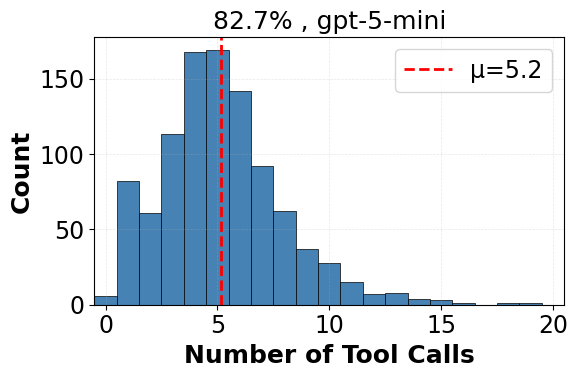

In [31]:
model_name = 'gpt-5-mini'

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.arange(0, 22) - 0.5

model_data = df_open[df_open['model'] == model_name]['num_sql_tool_calls']

ax.hist(model_data, bins=bins, edgecolor='black', linewidth=0.5, color='steelblue')
ax.set_title(f"{model_results[model_name]['accuracy']*100:.1f}% , {model_name}", fontsize=18, fontweight='light')
ax.set_xlim(-0.5, 20.5)
ax.set_xticks([0, 5, 10, 15, 20])
ax.tick_params(labelsize=17)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

mean_val = model_data.mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'μ={mean_val:.1f}')
ax.legend(fontsize=17, loc='upper right')

ax.set_xlabel('Number of Tool Calls', fontweight='bold', fontsize=18)
ax.set_ylabel('Count', fontweight='bold', fontsize=18)

plt.tight_layout()
#plt.savefig(config.plots_dir / f'tool_calls_{model_name}.pdf', bbox_inches='tight')
plt.show()

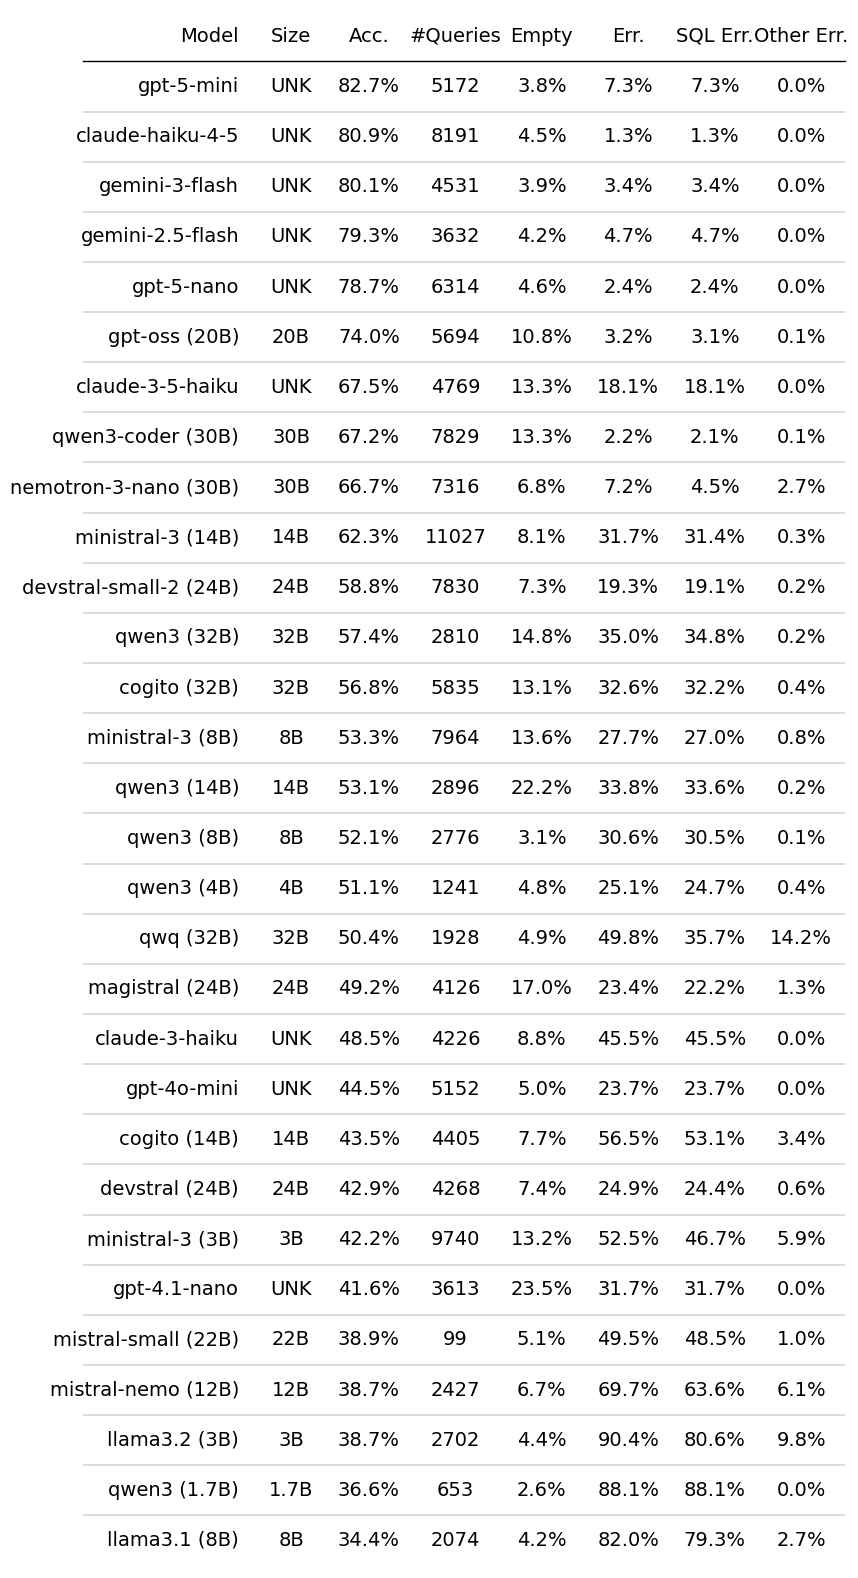

In [32]:
#half = int(len(sorted_models) / 2)

# Build the data
table_data = []
for model_name in sorted_models:  # Show only top half
    model_df = df_open[df_open['model'] == model_name]
    
    total_calls = model_df['num_sql_tool_calls'].sum()
    total_empty = model_df['num_tool_empty'].sum()
    total_errors = model_df['num_tool_errors'].sum()
    sql_errors = model_df['num_sql_errors'].sum()
    other_errors = model_df['num_other_errors'].sum()

    assert total_errors == sql_errors + other_errors, f"Total errors: {total_errors}, SQL errors: {sql_errors}, Other errors: {other_errors}"
    
    size_str = f"{info_dict[model_name]['params']}B" if info_dict[model_name]['params'] else "UNK"
    table_data.append({
        'Model': info_dict[model_name]['display_name_p'],
        'Size': size_str,
        'Accuracy (%)': model_results[model_name]['accuracy'] * 100,
        'Total Calls': int(total_calls),
        'Empty (%)': 100 * total_empty / total_calls if total_calls > 0 else 0,
        'Total Error': 100 * total_errors / total_calls if total_calls > 0 else 0,
        'SQL Error': 100 * sql_errors / total_calls if total_calls > 0 else 0,
        'Other Error': 100 * other_errors / total_calls if total_calls > 0 else 0,
    })

table_df = pd.DataFrame(table_data).set_index('Model')

# Plot
fig, ax = plt.subplots(figsize=(9, len(table_df) * 0.5 + 1))
ax.axis('off')

Table(
    table_df,
    ax=ax,
    column_definitions=[
        ColumnDefinition(name="Size", title="Size", width=0.4, textprops={"ha": "center"}),
        ColumnDefinition(name="Accuracy (%)", title="Acc.", width=0.5, formatter="{:.1f}%", textprops={"ha": "center"}),
        ColumnDefinition(name="Total Calls", title="#Queries", width=0.5, textprops={"ha": "center"}),
        ColumnDefinition(name="Empty (%)", title="Empty", width=0.5, formatter="{:.1f}%", textprops={"ha": "center"}),
        ColumnDefinition(name="Total Error", title="Err.", width=0.5, formatter="{:.1f}%", textprops={"ha": "center"}),
        ColumnDefinition(name="SQL Error", title="SQL Err.", width=0.5, formatter="{:.1f}%", textprops={"ha": "center"}),
        ColumnDefinition(name="Other Error", title="Other Err.", width=0.5, formatter="{:.1f}%", textprops={"ha": "center"})
    ]
)

plt.tight_layout()
plt.savefig(config.plots_dir / 'tool_call_stats.pdf', bbox_inches='tight')
plt.show()

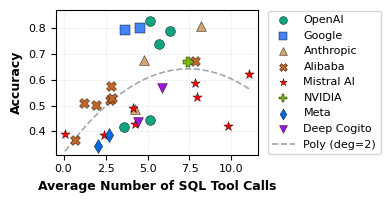

In [33]:
# Define markers and colors per creator
creator_styles = {
    'NVIDIA': {'marker': 'P', 'color': '#76b900'},
    'OpenAI': {'marker': 'o', 'color': '#10a37f'},
    'Google': {'marker': 's', 'color': '#4285f4'},
    'Anthropic': {'marker': '^', 'color': '#d4a574'},
    'Alibaba': {'marker': 'X', 'color': "#c46724"},
    'Mistral AI': {'marker': '*', 'color': "#ff0000"},
    'Meta': {'marker': 'd', 'color': '#0668e1'},
    'Deep Cogito': {'marker': 'v', 'color': "#a115d8"},
}

fig, ax = plt.subplots(figsize=(4.15, 2.25))

# Calculate average tool calls and accuracy per model
avg_tool_calls = []
accuracies = []
model_names = []

for model_name in models:
    model_data = df_open[df_open['model'] == model_name]
    if len(model_data) > 0:
        avg_tc = model_data['num_sql_tool_calls'].mean()
        acc = model_results[model_name]['accuracy']
        avg_tool_calls.append(avg_tc)
        accuracies.append(acc)
        model_names.append(model_name)

# Get creator info for coloring
creators = [info_dict[m]['creator'] for m in model_names]

# Plot each point with creator-specific styling
plotted_creators = set()
for model_name, avg_tc, acc, creator in zip(model_names, avg_tool_calls, accuracies, creators):
    style = creator_styles.get(creator, {'marker': 'o', 'color': 'gray'})
    label = creator if creator not in plotted_creators else None
    plotted_creators.add(creator)
    
    ax.scatter(avg_tc, acc, s=50, marker=style['marker'], color=style['color'],
               label=label, edgecolors='black', linewidths=0.3, zorder=5)

# Add polynomial trend line
x = np.array(avg_tool_calls)
y = np.array(accuracies)
degree = 2
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)

# Generate smooth line
x_smooth = np.linspace(x.min(), x.max(), 100)
y_smooth = poly(x_smooth)

ax.plot(x_smooth, y_smooth, color='gray', linestyle='--', linewidth=1.2, 
        alpha=0.7, zorder=1, label='Poly (deg=2)')

ax.set_xlabel('Average Number of SQL Tool Calls', fontsize=9, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.tick_params(labelsize=8)
ax.set_ylim(0.31, 0.87)

# Legend outside on the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, markerscale=0.8)

plt.tight_layout()
plt.savefig(config.plots_dir / 'tool_calls_vs_accuracy_compact.pdf', bbox_inches='tight')
plt.show()

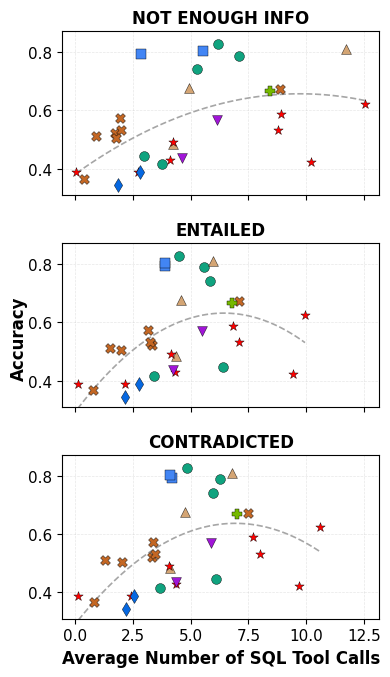

In [34]:
ground_truth_labels = ['NOT ENOUGH INFO', 'ENTAILED', 'CONTRADICTED']

fig, axes = plt.subplots(3, 1, figsize=(4, 7), sharex=True)

for ax, ground_truth_label in zip(axes, ground_truth_labels):
    df_gt = df_open[df_open['ground_truth'] == ground_truth_label]

    # Calculate average tool calls and accuracy per model
    avg_tool_calls = []
    accuracies = []
    model_names = []

    for model_name in models:
        model_data = df_gt[df_gt['model'] == model_name]
        if len(model_data) > 0:
            avg_tc = model_data['num_sql_tool_calls'].mean()
            acc = model_results[model_name]['accuracy']
            avg_tool_calls.append(avg_tc)
            accuracies.append(acc)
            model_names.append(model_name)

    # Get creator info for coloring
    creators = [info_dict[m]['creator'] for m in model_names]

    # Plot each point with creator-specific styling
    plotted_creators = set()
    for model_name, avg_tc, acc, creator in zip(model_names, avg_tool_calls, accuracies, creators):
        style = creator_styles.get(creator, {'marker': 'o', 'color': 'gray'})
        label = creator if creator not in plotted_creators else None
        plotted_creators.add(creator)
        
        ax.scatter(avg_tc, acc, s=50, marker=style['marker'], color=style['color'],
                label=label, edgecolors='black', linewidths=0.3, zorder=5)

    # Add polynomial trend line
    x = np.array(avg_tool_calls)
    y = np.array(accuracies)
    degree = 2
    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)

    # Generate smooth line
    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = poly(x_smooth)

    ax.plot(x_smooth, y_smooth, color='gray', linestyle='--', linewidth=1.2, 
            alpha=0.7, zorder=1, label='Poly (deg=2)')

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0.31, 0.87)
    ax.set_title(ground_truth_label, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=11)

# Single x-axis label at bottom
axes[-1].set_xlabel('Average Number of SQL Tool Calls', fontsize=12, fontweight='bold')

# Single y-axis label on the left (centered)
fig.text(0.02, 0.5, 'Accuracy', va='center', rotation='vertical', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig(config.plots_dir / 'tool_calls_per_label_vs_accuracy.pdf', bbox_inches='tight')
plt.show()

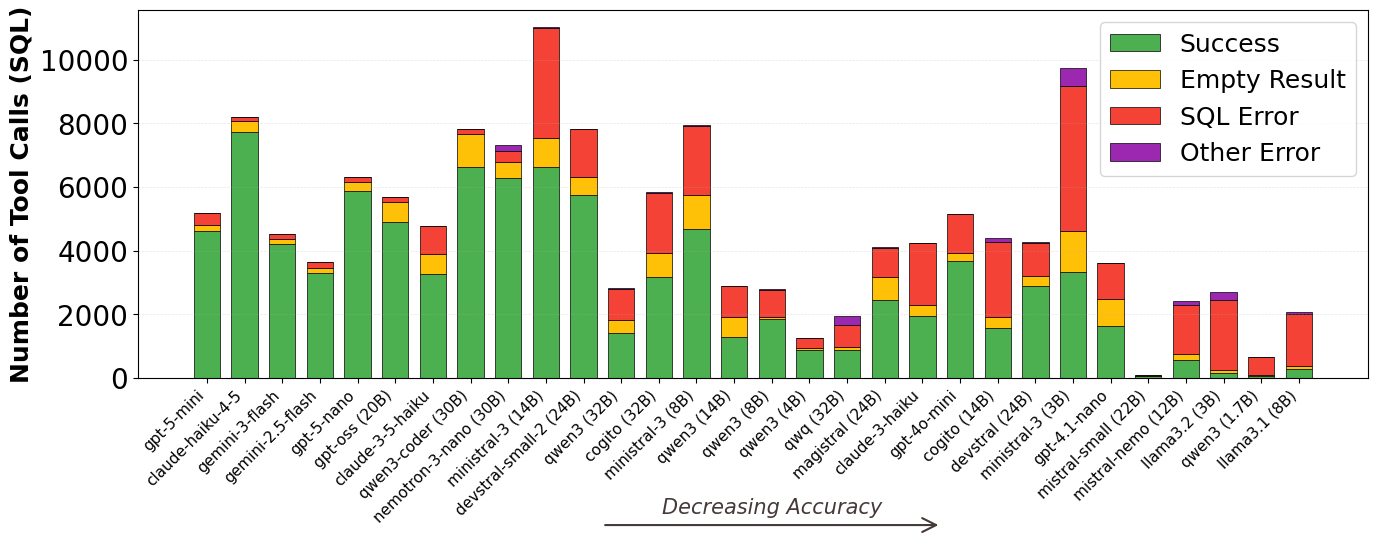

In [35]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate stats per model
model_stats = []
for model_name in sorted_models:
    model_data = df_open[df_open['model'] == model_name]
    if len(model_data) > 0:
        total_calls = model_data['num_sql_tool_calls'].sum()
        total_empty = model_data['num_tool_empty'].sum()
        sql_errors = model_data['num_sql_errors'].sum()
        other_errors = model_data['num_other_errors'].sum()
        total_errors = sql_errors + other_errors
        total_success = total_calls - total_empty - total_errors

        assert total_success > 0, f"Total calls: {total_calls}, empty: {total_empty}, errors: {total_errors}"
        
        model_stats.append({
            'model': model_name,
            'acc': model_results[model_name]['accuracy'],
            'success': total_success,
            'empty': total_empty,
            'sql_error': sql_errors,
            'other_error': other_errors,
            'display_name_p': info_dict[model_name]['display_name_p'],
        })

# Sort by accuracy
model_stats = sorted(model_stats, key=lambda x: x['acc'], reverse=True)

# Plot stacked bars
x = np.arange(len(model_stats))
bar_width = 0.7

success = [s['success'] for s in model_stats]
empty = [s['empty'] for s in model_stats]
sql_error = [s['sql_error'] for s in model_stats]
other_error = [s['other_error'] for s in model_stats]

ax.bar(x, success, bar_width, label='Success', color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.bar(x, empty, bar_width, bottom=success, label='Empty Result', color='#FFC107', edgecolor='black', linewidth=0.5)
ax.bar(x, sql_error, bar_width, bottom=np.array(success) + np.array(empty), label='SQL Error', color='#F44336', edgecolor='black', linewidth=0.5)
ax.bar(x, other_error, bar_width, bottom=np.array(success) + np.array(empty) + np.array(sql_error), label='Other Error', color='#9C27B0', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([s['display_name_p'] for s in model_stats], rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Number of Tool Calls (SQL)', fontsize=18, fontweight='bold')
ax.legend(loc='best', fontsize=18)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')


# Arrow settings
arrow_y = -0.4  # vertical position (in axes fraction, negative = below x-axis)
arrow_start = len(model_stats) * 0.35  # left end of arrow
arrow_end = len(model_stats) * 0.65  # right end of arrow
text_y = arrow_y + 0.03  # vertical position of text
arrow_color = "#453939"  # dark gray

ax.annotate('', xy=(arrow_end, arrow_y), 
            xytext=(arrow_start, arrow_y),
            xycoords=('data', 'axes fraction'),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color=arrow_color, lw=1.5, mutation_scale=25))
ax.text((arrow_start + arrow_end) / 2, text_y, 'Decreasing Accuracy', 
        ha='center', fontsize=15, fontstyle='italic', color=arrow_color,
        fontweight='medium',
        transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig(config.plots_dir / 'tool_outcome_stacked_bars_counts.pdf', bbox_inches='tight')
plt.show()

In [36]:
# TODO:
# Percentage of errors per experiment (plot line)
# Percentage of empty answer per experiment (plot line)
# Find if when you make a mistake and get an error, will you continue making mistakes?
# How many tool call errors per experiment?

"""
model_name = 'gpt-5-mini'
c_to_t = model_results[model_name]['c_to_t']

unique_
"""

"\nmodel_name = 'gpt-5-mini'\nc_to_t = model_results[model_name]['c_to_t']\n\nunique_\n"

## SQL Convergence

In [37]:
import tqdm

In [38]:
# key: model_name, value: convergence_dict
#   `convergence_dict` --> key: claim_id, value: list of floats (0-1) representing convergence (to gold SQL) 
#                          through CORRECT (non-erroneous) tool calls
claim_convergence = dict()


for model_name in tqdm.tqdm(models):
    #print(model_name)
    claim_convergence[model_name] = dict()
    c_to_t = model_results[model_name]['c_to_t']

    for claim_id in c_map.keys():
        qa_list = c_to_t[claim_id]
        bird_id = c_map[claim_id]['bird_id']
        gold_sql = b_map[bird_id]['SQL']

        convergence = []

        if qa_list is None:
            continue

        #print(gold_sql)
        for qa in qa_list:
            # only non-error (the error has a reason - cant parse). The reasoning intent is on the correct query
            if not qa.error:
                try:
                    #print(qa.query)
                    convergence.append(sql_diff_distance(gold_sql, qa.query))
                except Exception as e:
                    pass
                    #print(f"{model_name}, {claim_id}, oh fuck")
        #print()

        claim_convergence[model_name][claim_id] = convergence

 20%|██        | 6/30 [00:33<02:16,  5.69s/it]SQLite GROUP_CONCAT doesn't support ORDER BY.
SQLite GROUP_CONCAT doesn't support ORDER BY.
 27%|██▋       | 8/30 [00:43<01:48,  4.93s/it]Named columns are not supported in table alias.
Named columns are not supported in table alias.
 53%|█████▎    | 16/30 [01:18<01:08,  4.86s/it]'explain SELECT * FROM Diagnosis' contains unsupported syntax. Falling back to parsing as a 'Command'.
'EXPLAIN SELECT * FROM LabResults' contains unsupported syntax. Falling back to parsing as a 'Command'.
'explain select * from diagnosis' contains unsupported syntax. Falling back to parsing as a 'Command'.
 57%|█████▋    | 17/30 [01:23<01:03,  4.91s/it]'explain SELECT p.player_api_id, p.player_name, pa.overall_rating, substr(pa.date, 1, 4) as rating_ye' contains unsupported syntax. Falling back to parsing as a 'Command'.
'explain select p.player_api_id, p.player_name, pa.overall_rating, substr(pa.date, 1, 4) as rating_ye' contains unsupported syntax. Falling back

In [55]:
model = 'gpt-5-mini'
correct = True
ground_truth = 'NOT ENOUGH INFO'
allowed_claim_ids = df[
    (df['model'] == model_name) & 
    (df['correct'] == correct) & 
    (df['ground_truth'] == ground_truth)
]['claim_id'].values.tolist()

In [700]:
from matplotlib.ticker import MultipleLocator


def convergence_plot(df, model_name, ground_truth, num_select=10):

    # some claims are erroneous and we simply dont have a list (none above and skip)
    convergence_ids = list(claim_convergence[model_name].keys())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
    #fig.suptitle('SQL Convergence to "gold" SQL', fontsize=14, fontweight='bold')

    for idx, correct in enumerate([True, False]):

        ax = axes[idx]

        allowed_claim_ids = df[
            (df['model'] == model_name) & 
            (df['correct'] == correct) & 
            (df['ground_truth'] == ground_truth)
        ]['claim_id'].values.tolist()

        allowed_claim_ids = [cid for cid in allowed_claim_ids if cid in convergence_ids]

        print(len(allowed_claim_ids))

        if len(allowed_claim_ids) < num_select:
            num_select = len(allowed_claim_ids)

        sampled_ids = random.sample(allowed_claim_ids, num_select)

        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']
        colors = plt.cm.tab20b.colors

        for i, claim_id in enumerate(sampled_ids):
            convergence = claim_convergence[model_name][claim_id]
            x = range(1, len(convergence) + 1)
            
            ax.plot(x, convergence, 
                    marker=markers[i % len(markers)], 
                    color=colors[i % len(colors)],
                    label=f'{claim_id}',
                    linewidth=1.5,
                    markersize=6)
            
        title = f"{model_name}" + f" ({model_results[model_name]['accuracy']*100:.0f}%)" + " , " + f"{ground_truth} , " + f"{'CORRECT' if correct else 'INCORRECT'}"

        ax.set_xlabel('Successful Tool Call Idx', fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), fontsize=7, ncols=7)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.xaxis.set_major_locator(MultipleLocator(1))

    axes[0].set_ylabel('Distance to Gold SQL', fontsize=11, fontweight='bold')

    plt.subplots_adjust(wspace=-0.21)

    plt.tight_layout()
    plt.savefig(config.plots_dir / f'{model_name}.pdf', bbox_inches='tight')
    plt.show()

In [701]:
from matplotlib.ticker import MultipleLocator


def convergence_cum_min_plot(df, model_name, ground_truth, num_select=10):

    # some claims are erroneous and we simply dont have a list (none above and skip)
    convergence_ids = list(claim_convergence[model_name].keys())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
    #fig.suptitle('SQL Convergence to "gold" SQL', fontsize=14, fontweight='bold')

    for idx, correct in enumerate([True, False]):

        ax = axes[idx]

        allowed_claim_ids = df[
            (df['model'] == model_name) & 
            (df['correct'] == correct) & 
            (df['ground_truth'] == ground_truth)
        ]['claim_id'].values.tolist()

        allowed_claim_ids = [cid for cid in allowed_claim_ids if cid in convergence_ids]

        print(len(allowed_claim_ids))

        if len(allowed_claim_ids) < num_select:
            num_select = len(allowed_claim_ids)

        sampled_ids = random.sample(allowed_claim_ids, num_select)

        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']
        colors = plt.cm.tab20b.colors

        for i, claim_id in enumerate(sampled_ids):
            convergence = claim_convergence[model_name][claim_id]
            cumulative_min = np.minimum.accumulate(convergence)  # running minimum
            x = range(1, len(cumulative_min) + 1)
            
            ax.plot(x, cumulative_min, 
                    marker=markers[i % len(markers)], 
                    color=colors[i % len(colors)],
                    label=f'{claim_id}',
                    linewidth=1.5,
                    markersize=6)
            
        title = f"{model_name} , " + f"{ground_truth} , " + f"{'CORRECT' if correct else 'INCORRECT'}"

        ax.set_xlabel('Successful Tool Call Idx', fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), fontsize=7, ncols=7)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.xaxis.set_major_locator(MultipleLocator(1))

    axes[0].set_ylabel('Min Distance to Gold SQL', fontsize=11, fontweight='bold')

    plt.subplots_adjust(wspace=-0.21)

    plt.tight_layout()
    plt.savefig(config.plots_dir / f'{model_name}_min.pdf', bbox_inches='tight')
    plt.show()

266
67


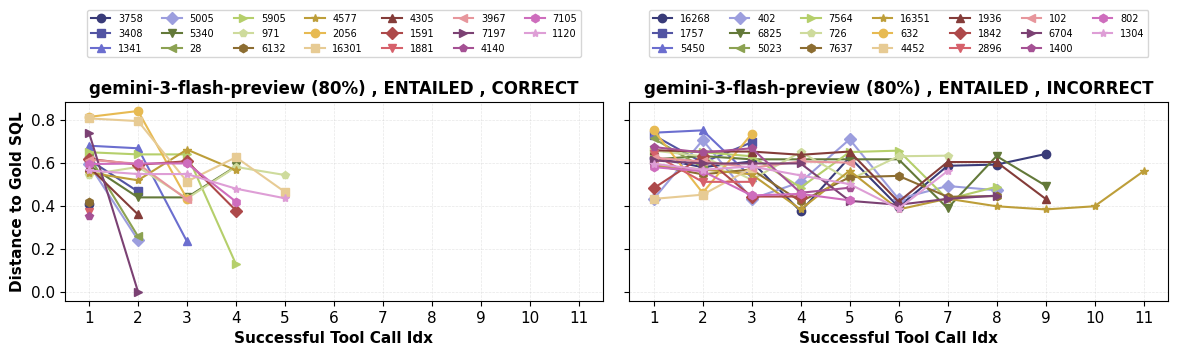

In [702]:
convergence_plot(df, 'gemini-3-flash-preview', 'ENTAILED', 20)

In [758]:
min([], default=None)

In [759]:
min_convergence = dict()

for model_name, convergence_dict in claim_convergence.items():
    min_convergence[model_name] = dict()
    
    for claim_id, claim_convergence_lst in convergence_dict.items():
        min_val = min(claim_convergence_lst, default=None)
        min_convergence[model_name][claim_id] = min_val

In [ ]:
min_convergence[model_name][claim_id]

In [763]:
df.columns

Index(['claim_id', 'verdict', 'ground_truth', 'category', 'db_name',
       'num_sql_tool_calls', 'num_tool_errors', 'num_sql_errors',
       'num_other_errors', 'num_tool_empty', 'correct', 'model'],
      dtype='str')

In [765]:
df['min_convergence'] = df.apply(
    lambda row: min_convergence.get(row['model'], {}).get(row['claim_id'], None),
    axis=1
)

In [784]:
df_no_nei = df[df['ground_truth'] != 'NOT ENOUGH INFO'].reset_index(drop=True)

df_no_nei['Prediction'] = df_no_nei['correct'].map({True: 'Correct', False: 'Incorrect'})

/var/folders/dh/qq0kgp497kz33pwykmj6fpwr0000gn/T/ipykernel_48082/2902743749.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)


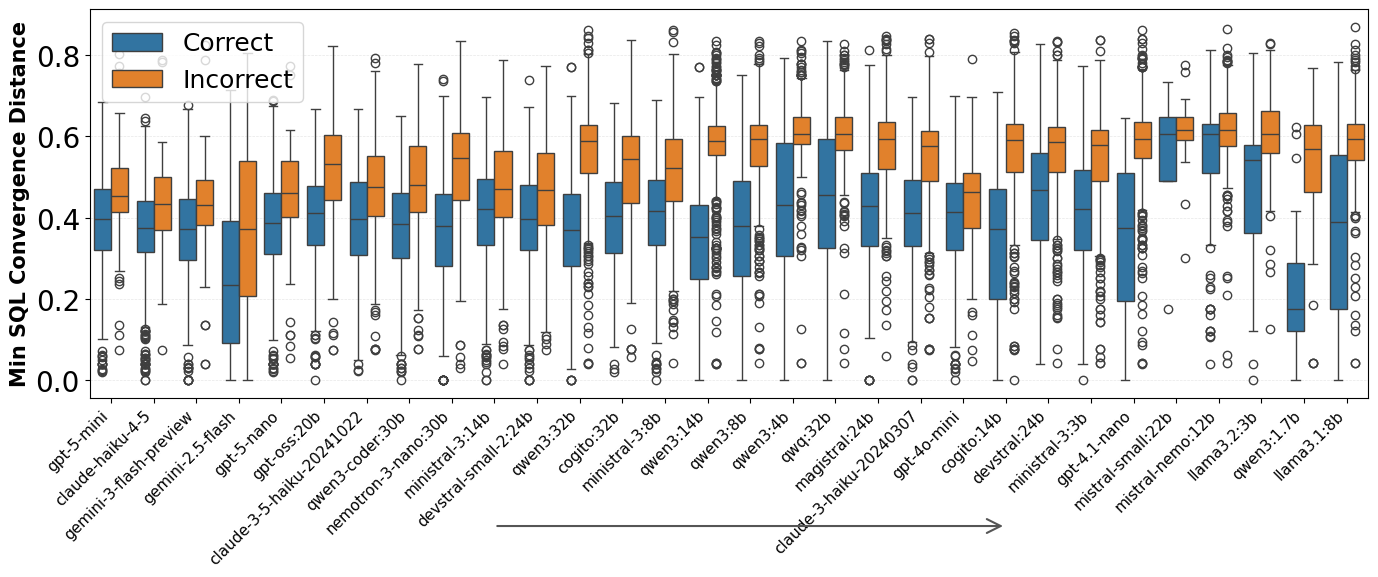

In [812]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_no_nei, 
    x='model', 
    y='min_convergence', 
    hue='Prediction',
    hue_order=['Correct', 'Incorrect'],
    order=sorted_models,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('Min SQL Convergence Distance', fontsize=15, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')

# Arrow settings
arrow_y = -0.33
arrow_start = len(sorted_models) * 0.3
arrow_end = len(sorted_models) * 0.7
text_y = arrow_y - 0.07
arrow_color = '#555555'

ax.annotate('', xy=(arrow_end, arrow_y), 
            xytext=(arrow_start, arrow_y),
            xycoords=('data', 'axes fraction'),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color=arrow_color, lw=1.5, mutation_scale=25))

plt.tight_layout()
plt.savefig(config.plots_dir / f'min_distance_correlation.pdf', bbox_inches='tight')
plt.show()

## End

In [41]:
#| hide
import nbdev; nbdev.nbdev_export()